In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df1 = pd.read_excel("TX_Power2.xlsx")

In [18]:
df1 = df1.rename(columns={
    "RSSI (dbm)": "RSSI",
    "Throughput (Kbps)": "Throughput",
    "Current (A)": "Current",
    "Power (W)": "Power"
})

In [19]:
# df_final = df1.drop(["Test", "Senarios", "Throughput (KB/S)" , "Unnamed: 7", "Unnamed: 8" "Unnamed: 9"], axis=1)
# df_final.dtypes

df_final = df1.drop(["Test", "Senarios", "Throughput (KB/S)" , "Unnamed: 9", "Current"], axis=1)
df_final.dtypes



KeyError: "['Unnamed: 9'] not found in axis"

In [ ]:
unique_values = df_final['Tx Power'].unique()
print(unique_values)


['N12' 'N9' 'N6' 'N3' 'N0' 'P3' 'P6' 'p9']


In [ ]:
df_final['Tx Power'] = df_final['Tx Power'].str.replace('N', '-', regex=False)
df_final['Tx Power'] = df_final['Tx Power'].str.replace('P', '+', regex=False)

In [ ]:
df_final['Tx Power'] = pd.to_numeric(df_final['Tx Power'], errors='coerce')
df_final['RSSI'] = pd.to_numeric(df_final['RSSI'], errors='coerce')
df_final['Throughput'] = pd.to_numeric(df_final['Throughput'], errors='coerce')


In [ ]:
df_final.head()
df_final.dtypes

Tx Power      float64
Distance        int64
RSSI            int64
Throughput    float64
Power         float64
dtype: object

In [ ]:
corr = df_final.corr(numeric_only=True)
print(corr)

            Tx Power  Distance      RSSI  Throughput     Power
Tx Power    1.000000  0.326739 -0.109625    0.173670  0.954983
Distance    0.326739  1.000000 -0.661432   -0.468314  0.226533
RSSI       -0.109625 -0.661432  1.000000    0.683234 -0.145314
Throughput  0.173670 -0.468314  0.683234    1.000000  0.250202
Power       0.954983  0.226533 -0.145314    0.250202  1.000000


ValueError: keyword rotation_angle is not recognized; valid keywords are ['size', 'width', 'color', 'tickdir', 'pad', 'labelsize', 'labelcolor', 'labelfontfamily', 'zorder', 'gridOn', 'tick1On', 'tick2On', 'label1On', 'label2On', 'length', 'direction', 'left', 'bottom', 'right', 'top', 'labelleft', 'labelbottom', 'labelright', 'labeltop', 'labelrotation', 'grid_agg_filter', 'grid_alpha', 'grid_animated', 'grid_antialiased', 'grid_clip_box', 'grid_clip_on', 'grid_clip_path', 'grid_color', 'grid_dash_capstyle', 'grid_dash_joinstyle', 'grid_dashes', 'grid_data', 'grid_drawstyle', 'grid_figure', 'grid_fillstyle', 'grid_gapcolor', 'grid_gid', 'grid_in_layout', 'grid_label', 'grid_linestyle', 'grid_linewidth', 'grid_marker', 'grid_markeredgecolor', 'grid_markeredgewidth', 'grid_markerfacecolor', 'grid_markerfacecoloralt', 'grid_markersize', 'grid_markevery', 'grid_mouseover', 'grid_path_effects', 'grid_picker', 'grid_pickradius', 'grid_rasterized', 'grid_sketch_params', 'grid_snap', 'grid_so

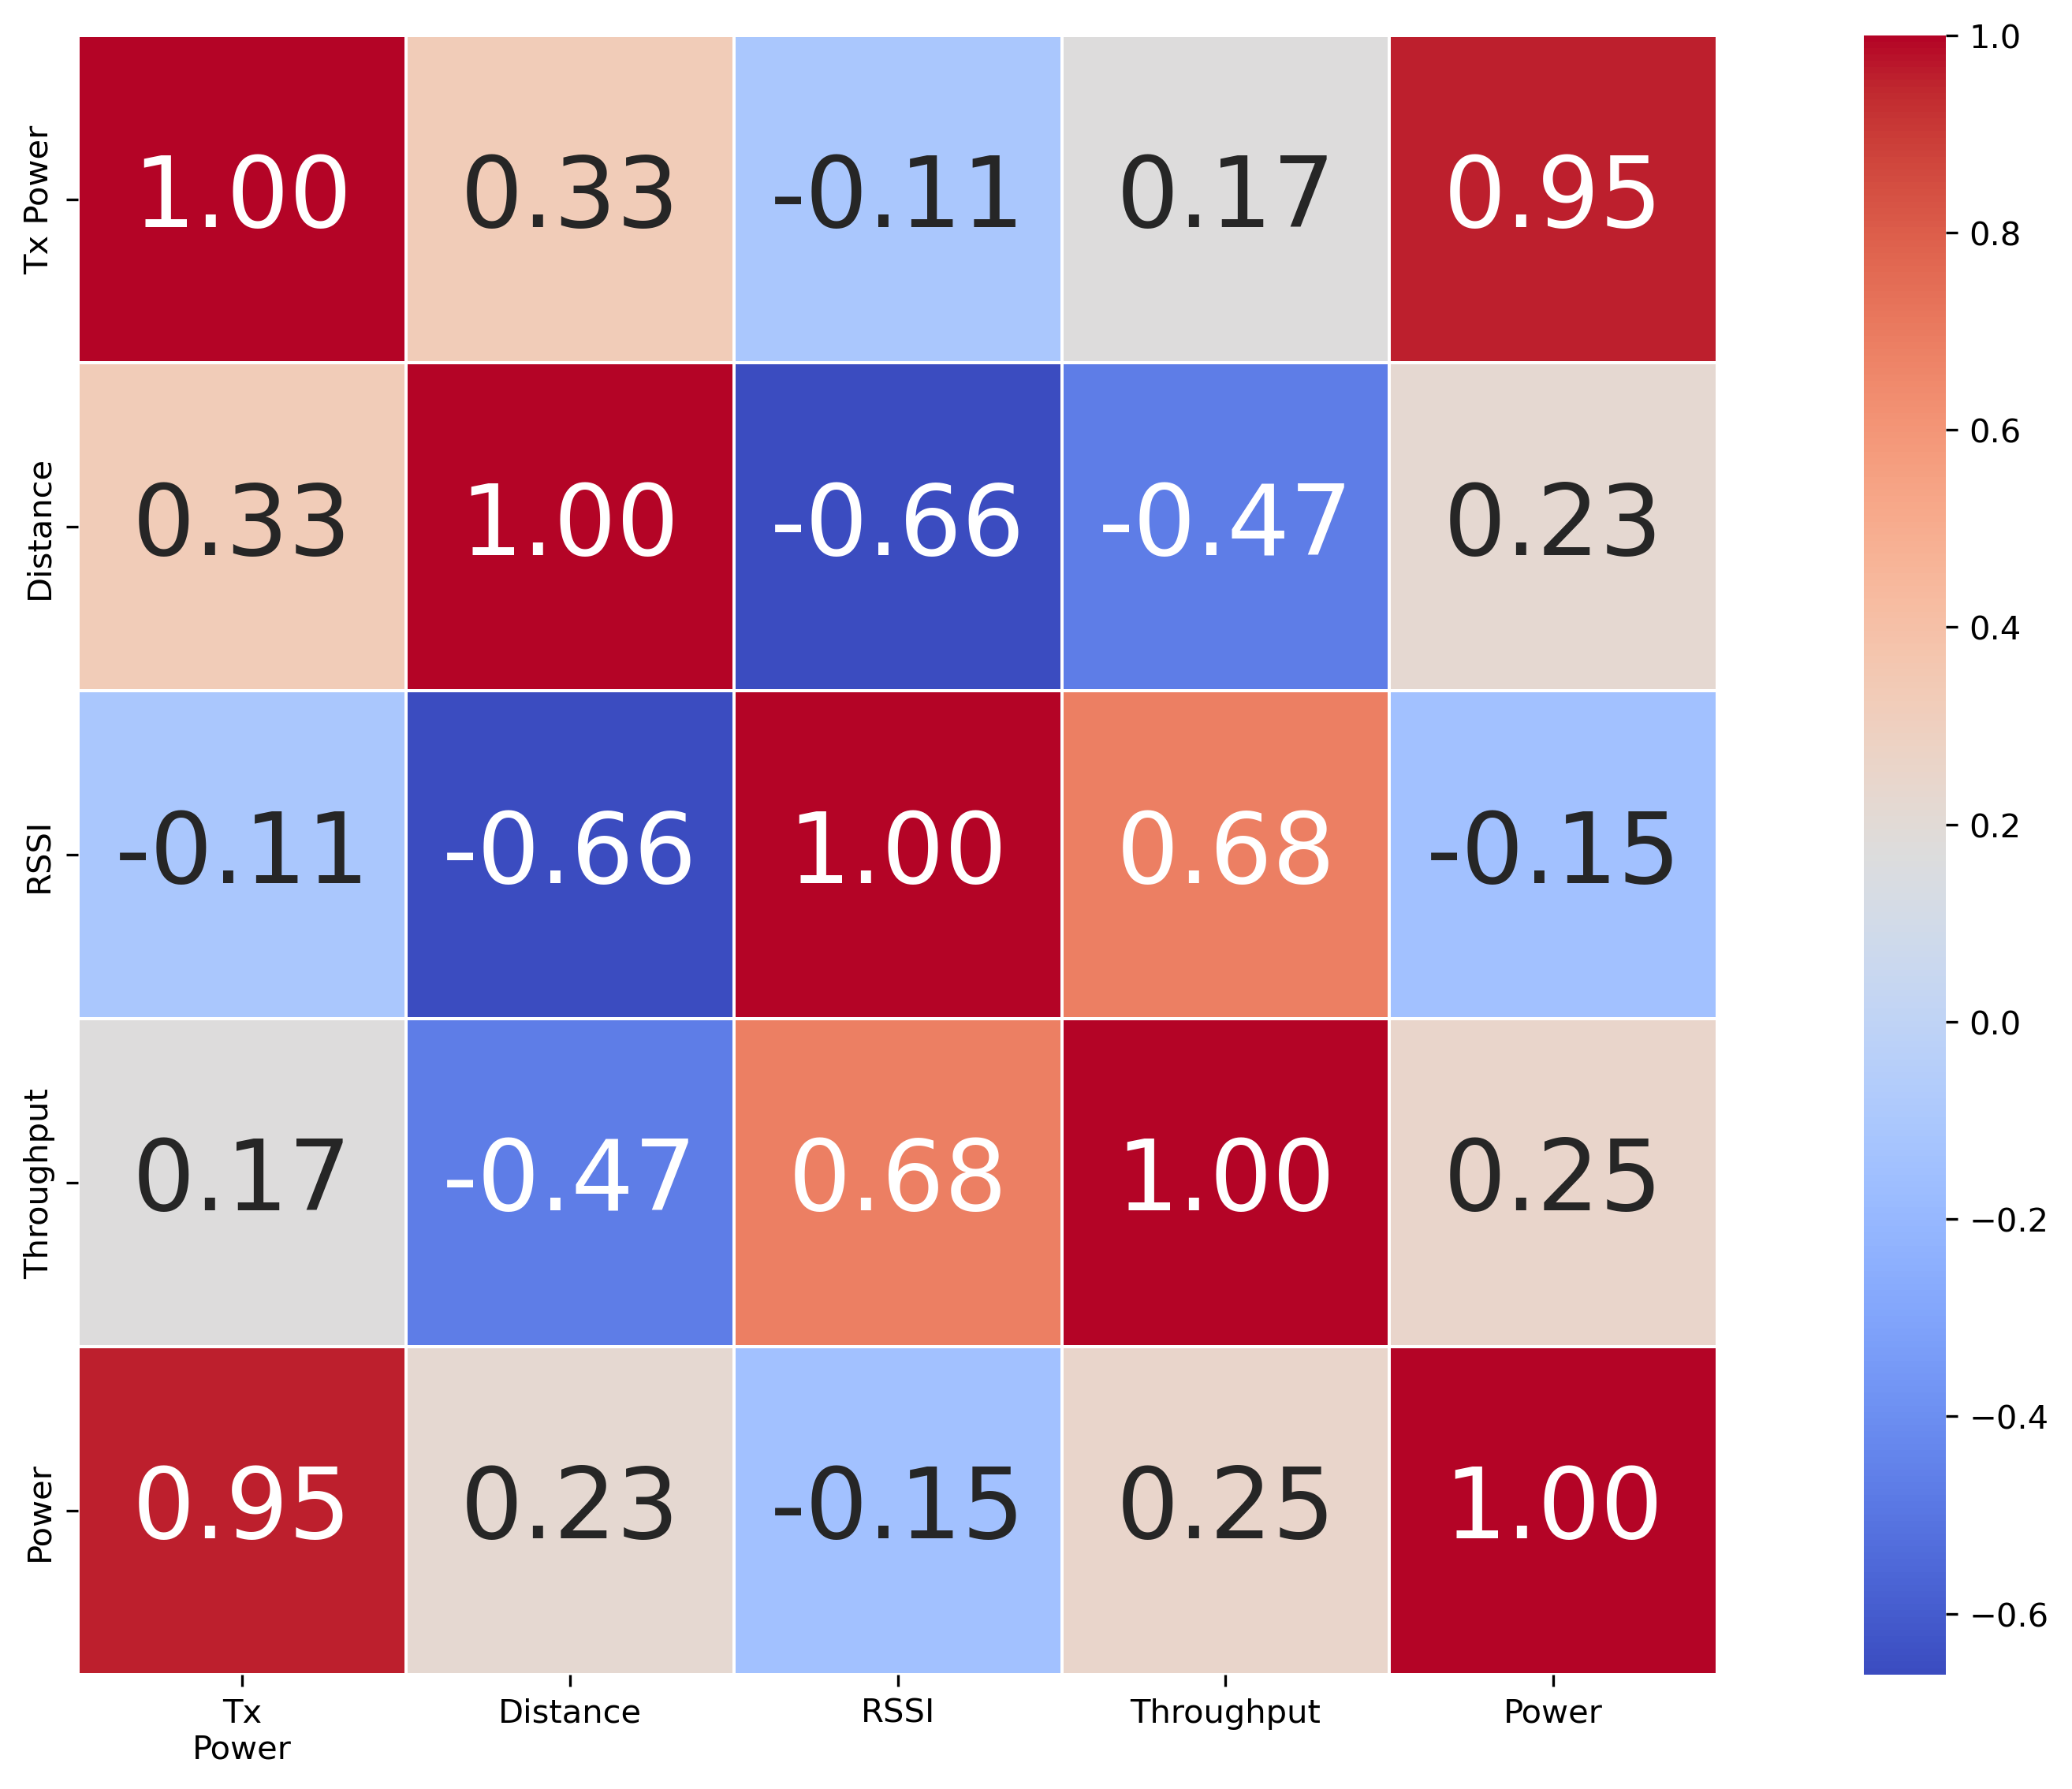

In [ ]:

corr_renamed = corr.copy()
corr_renamed.columns = [col.replace(' ', '\n') for col in corr.columns]

plt.figure(figsize=(16, 9), dpi=300)
ax = sns.heatmap(
    corr_renamed,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    cbar=True,
    square=True,
    linewidths=0.5,
    annot_kws={"size":30}  # cell annotations
)

# Increase colorbar tick labels
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=30, rotation=90)  # change number size

plt.xticks(rotation=0, ha='center', fontsize=30)
plt.yticks(rotation=0, fontsize=30)
plt.tight_layout()
plt.show()
